CNN

In [ ]:
# Import libraries
import os
import random
import numpy as np
import tensorflow as tf
import cv2
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
# Seeding
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Import dataset
path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(path)
# Count the number of images
normal_dir=os.path.join(path,"normal")
cataract_dir=os.path.join(path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# Load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# Load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
# Normalization
x=x/255.0
print(x.shape)
print(y.shape)
# Splitting data into test train valid
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, stratify=y,random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp,random_state=42)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
# Class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights=dict(enumerate(class_weights))
print(class_weights)

datagen=ImageDataGenerator(rotation_range=20,width_shift_range=0.1,height_shift_range=0.1,shear_range=0.2,zoom_range=0.2,horizontal_flip=True,fill_mode='nearest')
datagen.fit(x_train)
# Build cnn model
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(img_size,img_size,3)),MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu'),MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

# Train the model
history=model.fit(datagen.flow(x_train,y_train,batch_size=32),epochs=25,validation_data=(x_val,y_val),class_weight=class_weights)

{0: np.float64(0.9836956521739131), 1: np.float64(1.0168539325842696)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 197s 5s/step - accuracy: 0.6575 - loss: 0.6229 - val_accuracy: 0.7417 - val_loss: 0.5007
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 193s 5s/step - accuracy: 0.7119 - loss: 0.5668 - val_accuracy: 0.7607 - val_loss: 0.4760
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 222s 6s/step - accuracy: 0.7522 - loss: 0.5038 - val_accuracy: 0.8081 - val_loss: 0.4186
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - accuracy: 0.7632 - loss: 0.4752 - val_accuracy: 0.6611 - val_loss: 0.7705
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.7964 - loss: 0.4476 - val_accuracy: 0.8081 - val_loss: 0.5643
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 192s 5s/step - accuracy: 0.8556 - loss: 0.3551 - val_accuracy: 0.8175 - val_loss: 0.5735
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.8713 - loss: 0.3238 - val_accuracy: 0.8294 - val_loss: 0.4878
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 200s 5s/step - accuracy: 0.8666 - loss: 0.3297 - val_accuracy: 0.8602 - v

In [ ]:
loss,accuracy=model.evaluate(x_test,y_test)
print("loss:",loss)
print("accuracy:",accuracy)
from sklearn.metrics import classification_report,confusion_matrix
y_pred=model.predict(x_test)
y_pred=np.round(y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8487 - loss: 0.3574
loss: 0.35744574666023254
accuracy: 0.8486997485160828
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
              precision    recall  f1-score   support

           0       0.78      0.97      0.87       215
           1       0.96      0.72      0.82       208

    accuracy                           0.85       423
   macro avg       0.87      0.85      0.85       423
weighted avg       0.87      0.85      0.85       423

[[209   6]
 [ 58 150]]


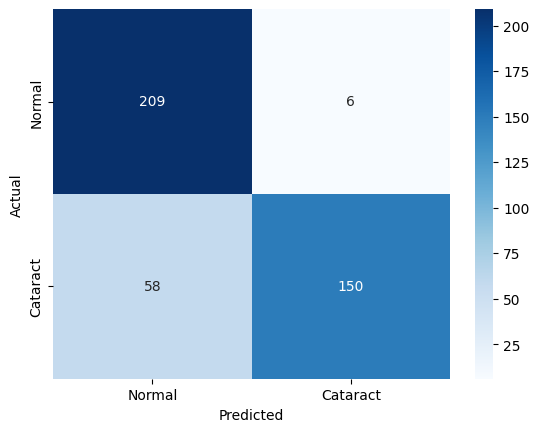

In [ ]:
# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cataract'], yticklabels=['Normal','Cataract'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8706758395976661
Recall: 0.8486997635933806
F1-score: 0.8460540273906567


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.9615384615384616
Recall: 0.7211538461538461
F1 Score: 0.8241758241758241


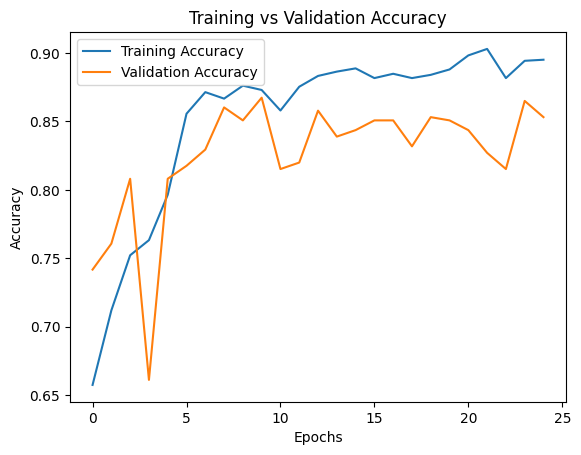

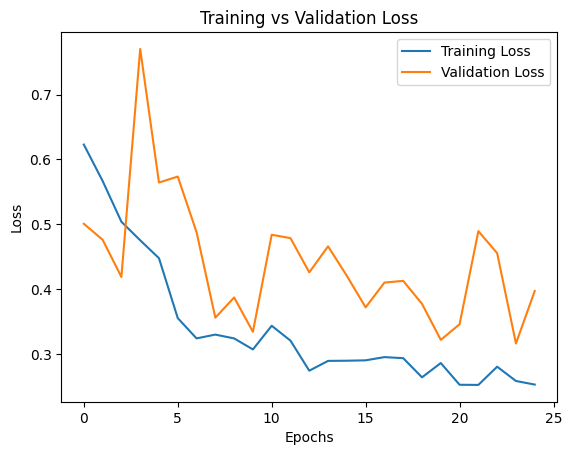

In [ ]:
# Plot accuracy graph
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()
plt.figure()
# Plot loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 735ms/step
AUC: 0.9528622540250448


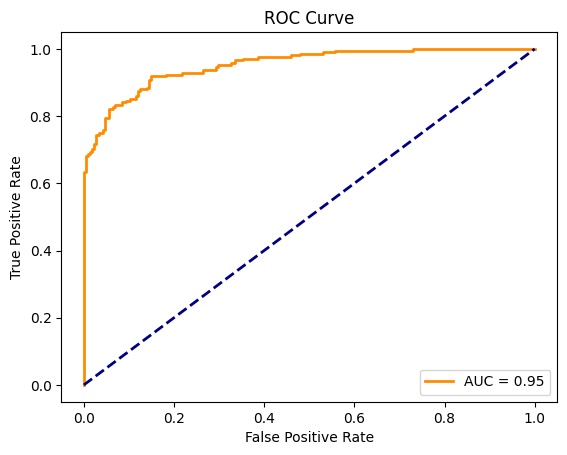

In [ ]:
# Plot roc curve
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_pred_prob = model.predict(x_test)
# compute roc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
# compute auc
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)
# plot graphs
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label= "AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Prediction
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
uploaded= files.upload()
for fname in uploaded.keys():
  img=cv2.imread(fname)
  img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  img=cv2.resize(img,(img_size,img_size))
  img=img/255.0
  img=np.expand_dims(img,axis=0)
  probs=model.predict(img)
  print(probs)
  label="cataract" if probs[0][0]>=0.5 else "normal"
  print(f"{fname}: {label} (prob={probs[0][0]:.2f})")

Saving nor5.jpg to nor5.jpg
Saving c5.jpg to c5.jpg
Saving c4.jpg to c4.jpg
Saving Cataract image.jpg to Cataract image.jpg
Saving c2.jpg to c2.jpg
Saving c1.jpg to c1.jpg
Saving nor4.jpg to nor4.jpg
Saving Normal Image.jpg to Normal Image.jpg
Saving nor2.jpg to nor2.jpg
Saving nor1.jpg to nor1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[[0.0542375]]
nor5.jpg: normal (prob=0.05)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0.52065665]]
c5.jpg: cataract (prob=0.52)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[0.74482036]]
c4.jpg: cataract (prob=0.74)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[0.63661134]]
Cataract image.jpg: cataract (prob=0.64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[0.05386089]]
c2.jpg: normal (prob=0.05)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.20247114]]
c1.jpg: normal (prob=0.20)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[0.09138266]]
nor4.jpg: normal (prob=0.09)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[[0.00205955]]
Normal Image.jpg: normal (prob=0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6

MobileNetV2

In [ ]:
# Import libraries
import os
import random
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Seeding
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Load data
from google.colab import drive
path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(path)
# Count the number of images
normal_dir=os.path.join(path,"normal")
cataract_dir=os.path.join(path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# Load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# Load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

train_gen=ImageDataGenerator(rotation_range=10,width_shift_range=0.1,height_shift_range=0.1,zoom_range=0.2,horizontal_flip=True)
val_gen=ImageDataGenerator()

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights=dict(enumerate(class_weights))
print(class_weights)
# Load model
base_model=MobileNetV2(weights="imagenet",include_top=False,input_shape=(img_size,img_size,3))
base_model.trainable=False
x= base_model.output
x= GlobalAveragePooling2D()(x)
x= Dense(128,activation="relu")(x)
x= Dropout(0.5)(x)
output=Dense(1,activation="sigmoid")(x)
model=Model(inputs=base_model.input,outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4),loss="binary_crossentropy",metrics=["accuracy"])
model.summary()
history=model.fit(train_gen.flow(x_train,y_train,batch_size=32),epochs=25,validation_data=val_gen.flow(x_val,y_val),class_weight=class_weights)
loss,accuracy=model.evaluate(x_test,y_test)
print("loss:",loss)
print("accuracy:",accuracy)
from sklearn.metrics import classification_report,confusion_matrix
y_pred=model.predict(x_test)
y_pred=np.round(y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

{0: np.float64(0.9836956521739131), 1: np.float64(1.0168539325842696)}
Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7995 - loss: 0.4468 - val_accuracy: 0.9313 - val_loss: 0.2102
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9274 - loss: 0.2110 - val_accuracy: 0.9408 - val_loss: 0.1578
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9416 - loss: 0.1717 - val_accuracy: 0.9408 - val_loss: 0.1372
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9392 - loss: 0.1638 - val_accuracy: 0.9479 - val_loss: 0.1261
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.9408 - loss: 0.1501 - val_accuracy: 0.9526 - val_loss: 0.1239
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9487 - loss: 0.1499 - val_accuracy: 0.9550 - val_loss: 0.1161
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9566 - loss: 0.1174 - val_accuracy: 0.9597 - val_loss: 0.1096
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/

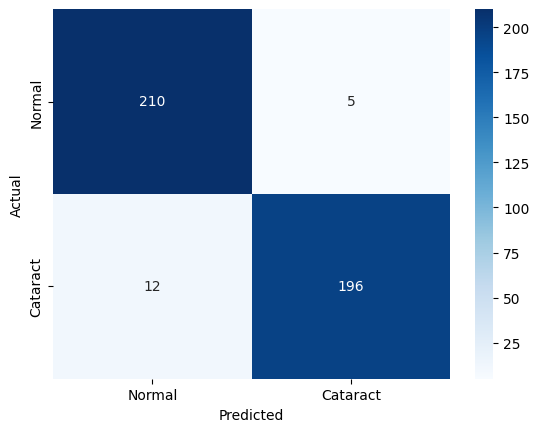

In [ ]:
# Plot Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cataract'], yticklabels=['Normal','Cataract'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

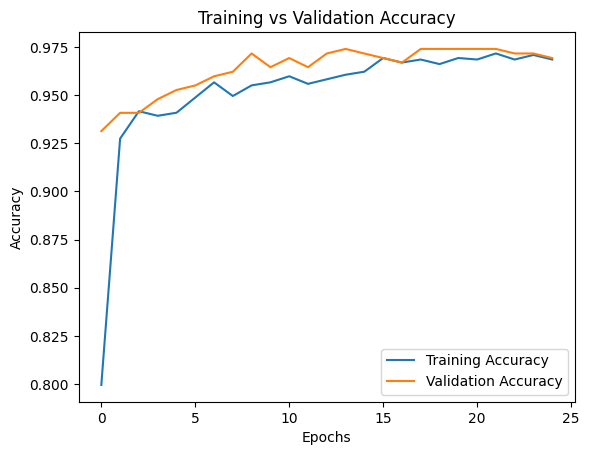

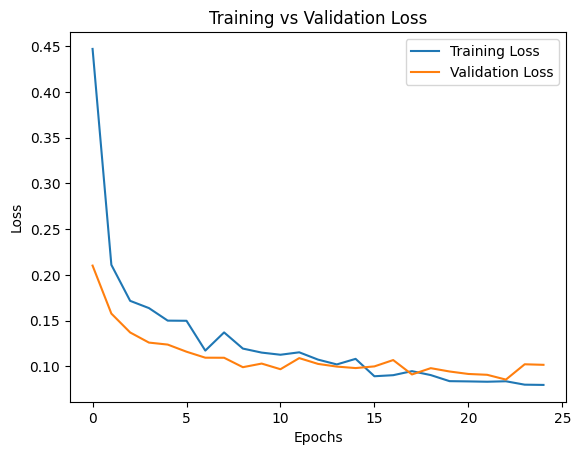

In [ ]:
# Plot accuracy graph
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()
plt.figure()
# Plot loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
AUC: 0.9938059033989267


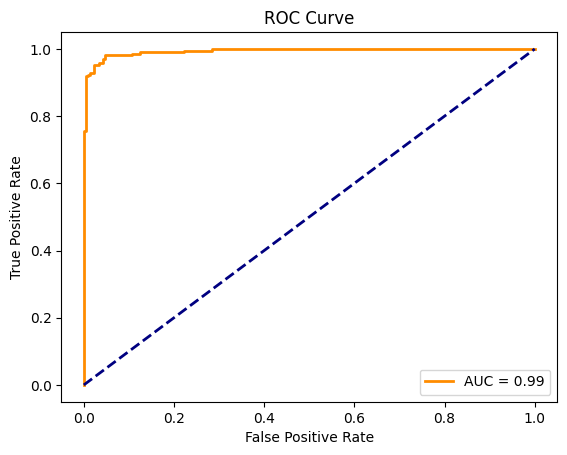

In [ ]:
# ROC curve
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_pred_prob = model.predict(x_test)
# compute roc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
# compute auc
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)
# plot graphs
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label= "AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Prediction
from tensorflow.keras.utils import load_img, img_to_array
from google.colab import files

uploaded = files.upload()
for fname in uploaded.keys():
    img = load_img(fname, target_size=(img_size, img_size))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    prob = model.predict(img)[0][0]
    label = "Cataract" if prob >= 0.5 else "Normal"
    print(f"{fname} → {label} (prob={prob:.2f})")

Saving nor5.jpg to nor5 (1).jpg
Saving c5.jpg to c5 (1).jpg
Saving c4.jpg to c4 (1).jpg
Saving Cataract image.jpg to Cataract image (1).jpg
Saving c2.jpg to c2 (1).jpg
Saving c1.jpg to c1 (1).jpg
Saving nor4.jpg to nor4 (1).jpg
Saving Normal Image.jpg to Normal Image (1).jpg
Saving nor2.jpg to nor2 (1).jpg
Saving nor1.jpg to nor1 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
nor5 (1).jpg → Normal (prob=0.37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
c5 (1).jpg → Cataract (prob=0.93)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
c4 (1).jpg → Cataract (prob=0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Cataract image (1).jpg → Cataract (prob=0.97)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
c2 (1).jpg → Cataract (prob=0.72)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
c1 (1).jpg → Cataract (prob=0.83)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
nor4 (1).jpg → Normal (prob=0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Normal Image (1).jpg → Normal (prob=0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
nor2 (1).jpg → Norma

EfficientNet

In [ ]:
# Import libraries
import os
import random
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Seeding
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Load data
from google.colab import drive
path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(path)
# Count the number of images
normal_dir=os.path.join(path,"normal")
cataract_dir=os.path.join(path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# Load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# Load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

train_gen=ImageDataGenerator(rotation_range=10,width_shift_range=0.1,height_shift_range=0.1,zoom_range=0.2,horizontal_flip=True)
val_gen=ImageDataGenerator()

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights=dict(enumerate(class_weights))
print(class_weights)
base_model=EfficientNetB0(weights="imagenet",include_top=False,input_shape=(img_size,img_size,3))
base_model.trainable=False
x= base_model.output
x= GlobalAveragePooling2D()(x)
x= Dense(128,activation="relu")(x)
x= Dropout(0.5)(x)
output=Dense(1,activation="sigmoid")(x)
model=Model(inputs=base_model.input,outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4),loss="binary_crossentropy",metrics=["accuracy"])
model.summary()
history=model.fit(train_gen.flow(x_train,y_train,batch_size=32),epochs=25,validation_data=val_gen.flow(x_val,y_val),class_weight=class_weights)
# Fine tuning
base_model.trainable=True
for layer in base_model.layers[:-50]:
    layer.trainable=False
model.compile(optimizer=Adam(learning_rate=1e-4),loss="binary_crossentropy",metrics=["accuracy"])
history=model.fit(train_gen.flow(x_train,y_train,batch_size=32),epochs=15,validation_data=val_gen.flow(x_val,y_val),class_weight=class_weights)

loss,accuracy=model.evaluate(x_test,y_test)
print("loss:",loss)
print("accuracy:",accuracy)
from sklearn.metrics import classification_report,confusion_matrix
y_pred=model.predict(x_test)
y_pred=np.round(y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

{0: np.float64(0.9836956521739131), 1: np.float64(1.0168539325842696)}
Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.8398 - loss: 0.4380 - val_accuracy: 0.9194 - val_loss: 0.2762
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.9195 - loss: 0.2508 - val_accuracy: 0.9171 - val_loss: 0.2193
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.9290 - loss: 0.2040 - val_accuracy: 0.9171 - val_loss: 0.1856
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.9448 - loss: 0.1724 - val_accuracy: 0.9242 - val_loss: 0.1648
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.9416 - loss: 0.1735 - val_accuracy: 0.9336 - val_loss: 0.1603
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.9463 - loss: 0.1603 - val_accuracy: 0.9384 - val_loss: 0.1559
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.9511 - loss: 0.1568 - val_accuracy: 0.9502 - val_loss: 0.1342
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 14

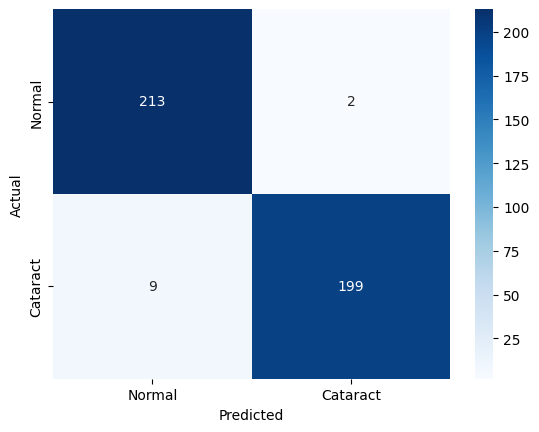

In [ ]:
# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cataract'], yticklabels=['Normal','Cataract'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

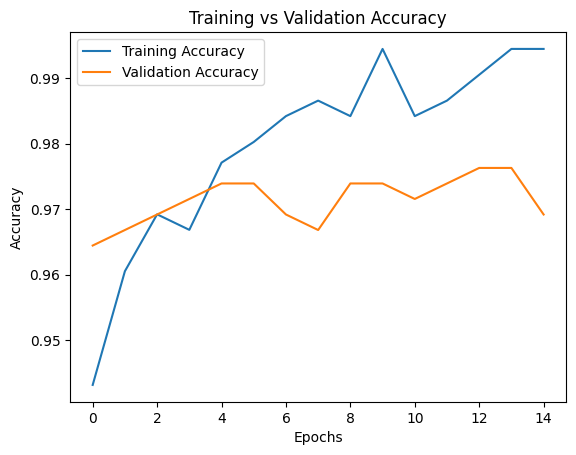

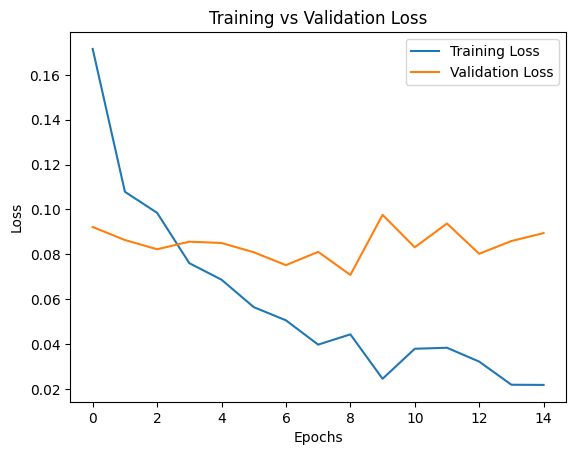

In [ ]:
# Plot training vs validation accuracy graph
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()
plt.figure()
# Plot training vs validation loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step
AUC: 0.9970483005366726


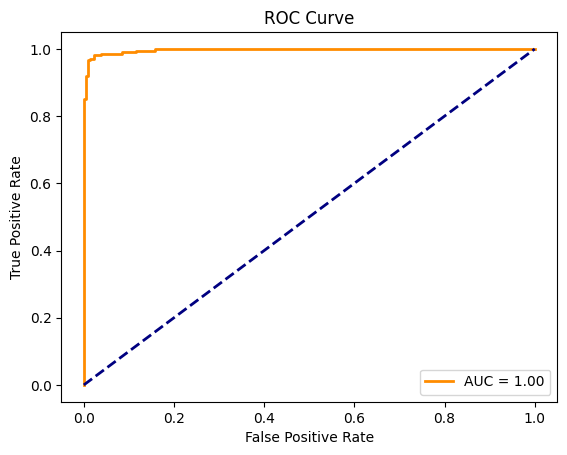

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_pred_prob = model.predict(x_test)
# compute roc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
# compute auc
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)
# plot graphs
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label= "AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Prediction
from tensorflow.keras.utils import load_img, img_to_array
from google.colab import files

uploaded = files.upload()
for fname in uploaded.keys():
    img = load_img(fname, target_size=(img_size, img_size))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    prob = model.predict(img)[0][0]
    label = "Cataract" if prob >= 0.5 else "Normal"
    print(f"{fname} → {label} (prob={prob:.2f})")

Saving nor5.jpg to nor5 (4).jpg
Saving c5.jpg to c5 (4).jpg
Saving c4.jpg to c4 (4).jpg
Saving Cataract image.jpg to Cataract image (6).jpg
Saving c2.jpg to c2 (4).jpg
Saving c1.jpg to c1 (4).jpg
Saving nor4.jpg to nor4 (4).jpg
Saving Normal Image.jpg to Normal Image (5).jpg
Saving nor2.jpg to nor2 (4).jpg
Saving nor1.jpg to nor1 (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
nor5 (4).jpg → Normal (prob=0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
c5 (4).jpg → Cataract (prob=0.91)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
c4 (4).jpg → Cataract (prob=1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Cataract image (6).jpg → Cataract (prob=1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
c2 (4).jpg → Cataract (prob=0.94)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
c1 (4).jpg → Cataract (prob=0.97)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
nor4 (4).jpg → Normal (prob=0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Normal Image (5).jpg → Normal (prob=0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
nor2 (4).jpg → No